# 01 - Exploratory Data Analysis

**Phase 1 (Weeks 1-2)** of the Portuguese wildfire catastrophe loss model.

This notebook fetches real annual wildfire statistics for Portugal, derives a
per-fire event table consistent with those real aggregates, and explores the
resulting frequency and severity patterns.

See `docs/phase1-plan.md` in the repo root for the full data-sourcing plan
and the reasoning behind the approach used here. In short:

- EFFIS's own Statistics Portal has no public JSON API (it's a JS single-page
  app), so annual fire-count and burnt-area series are fetched live from Our
  World in Data's mirror of GWIS (Global Wildfire Information System,
  JRC/Copernicus - the same body that runs EFFIS), which does expose a plain
  CSV endpoint.
- No public source publishes verified EUR loss per individual fire. A
  documented EUR/ha calibration constant (derived from published ICNF/OECD
  aggregate figures) is applied instead.
- Individual fire records (date, location, size) are not freely available
  without EFFIS's manual Data Request Form (submitted separately, turnaround
  unknown). Per-fire records here are therefore synthesized to match the real
  annual totals exactly - real frequency and real total severity, illustrative
  individual records. This is documented in full in "Data gaps and
  assumptions" below.

## Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import requests

from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY = "Portugal"
RNG = np.random.default_rng(seed=42)

## Data loading

Live fetches of real annual aggregates, plus the documented loss calibration
reference table.

In [2]:
def fetch_annual_fire_counts(country: str = COUNTRY,
                              save_path: Path = RAW_DIR / "effis_annual_fire_counts.csv") -> pd.DataFrame:
    """Fetch annual wildfire counts for a country.

    Source: Our World in Data's mirror of GWIS (Global Wildfire Information
    System, JRC/Copernicus - the same body behind EFFIS) annual fire-count
    series. EFFIS's own Statistics Portal is a JS single-page app with no
    public JSON endpoint, so this live CSV mirror is used instead. Coverage
    starts in 2012 (when VIIRS data became available), not the full
    2010-2024 window originally targeted - see Data gaps below.

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, fire_count (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-number-of-fires.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Annual number of fires": "fire_count"}
    )
    return df[["year", "fire_count"]].sort_values("year").reset_index(drop=True)

In [3]:
def fetch_annual_burnt_area(country: str = COUNTRY,
                             save_path: Path = RAW_DIR / "gwis_annual_burnt_area.csv") -> pd.DataFrame:
    """Fetch annual burnt area (hectares) for a country.

    Source: Our World in Data's mirror of GWIS's MODIS-derived annual
    burnt-area-by-region series. Used in place of a separate raw MODIS
    pull, since GWIS's burnt-area product already ingests MODIS.

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, burnt_area_ha (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-area-burnt-by-wildfires-gwis.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Yearly burned area across all land types": "burnt_area_ha"}
    )
    return df[["year", "burnt_area_ha"]].sort_values("year").reset_index(drop=True)

In [4]:
def build_loss_calibration(save_path: Path = RAW_DIR / "annual_loss_calibration.csv") -> pd.DataFrame:
    """Build (and persist) the EUR/ha loss calibration reference table.

    No public source publishes verified EUR loss per individual fire.
    Figures below are period/annual aggregates from published reports,
    used to derive documented EUR/ha calibration constants.

    Sources:
    - Long-run average: ICNF-derived cumulative figures for 1975-2021
      (~5.2M ha burnt, >EUR 10bn in losses) imply ~EUR 1,923/ha.
    - 2017 (catastrophic year): ~EUR 1.5bn total losses (June + October
      fires) against 523,552 ha burnt that year (see
      fetch_annual_burnt_area) implies ~EUR 2,865/ha - notably above the
      long-run average, reflecting a wildland-urban-interface year with
      high fatality and structure-loss shares relative to area burned.

    Returns
    -------
    pd.DataFrame
        Columns: label, eur_per_ha, source.
    """
    calibration = pd.DataFrame([
        {
            "label": "long_run_1975_2021",
            "eur_per_ha": 10_000_000_000 / 5_200_000,
            "source": "ICNF cumulative 1975-2021 burnt area & losses, via OECD/press reporting",
        },
        {
            "label": "catastrophic_2017",
            "eur_per_ha": 1_500_000_000 / 523_552,
            "source": "2017 fire season total losses vs. 2017 burnt area (October 2017 Iberian wildfires)",
        },
    ])
    save_path.write_text(calibration.to_csv(index=False), encoding="utf-8")
    return calibration

## Synthesizing per-fire records

The two live fetches above give real annual aggregates (fire count, total
burnt area) but not individual fire records. `synthesize_fire_events` builds
one row per real fire in each year, with sizes drawn from a heavy-tailed
shape and rescaled so each year's total exactly matches the real GWIS burnt
area figure. Real frequency and real total severity are preserved;
individual-record detail (exact date, location, single-fire size) is
illustrative rather than ground truth. See "Data gaps and assumptions".

In [5]:
def _fire_season_weights() -> np.ndarray:
    """Day-of-year sampling weights peaking in Portugal's July-September fire season."""
    days = np.arange(1, 366)
    peak = 227  # mid-August
    weights = np.exp(-0.5 * ((days - peak) / 45) ** 2) + 0.05
    return weights / weights.sum()

In [6]:
def synthesize_fire_events(fire_counts: pd.DataFrame, burnt_area: pd.DataFrame,
                            eur_per_ha: float, rng: np.random.Generator = RNG) -> pd.DataFrame:
    """Synthesize per-fire records constrained to match real annual aggregates.

    Parameters
    ----------
    fire_counts : pd.DataFrame
        Output of fetch_annual_fire_counts (columns: year, fire_count).
    burnt_area : pd.DataFrame
        Output of fetch_annual_burnt_area (columns: year, burnt_area_ha).
    eur_per_ha : float
        Calibration constant converting burnt area to estimated loss.
    rng : np.random.Generator
        Random generator for reproducibility.

    Returns
    -------
    pd.DataFrame
        Columns: Date, Location, Burned_Area_ha, Estimated_Loss_EUR - one
        row per synthesized fire event, sorted by date.
    """
    merged = pd.merge(fire_counts, burnt_area, on="year", how="inner")
    regions = ["Norte", "Centro", "Lisboa e Vale do Tejo", "Alentejo", "Algarve"]
    season_weights = _fire_season_weights()
    records = []

    for _, row in merged.iterrows():
        year = int(row["year"])
        n_fires = int(row["fire_count"])
        total_ha = float(row["burnt_area_ha"])
        if n_fires <= 0 or total_ha <= 0:
            continue

        raw_sizes = rng.lognormal(mean=0.0, sigma=1.2, size=n_fires)
        sizes = raw_sizes * (total_ha / raw_sizes.sum())

        day_of_year = rng.choice(np.arange(1, 366), size=n_fires, p=season_weights)
        dates = pd.to_datetime(f"{year}-01-01") + pd.to_timedelta(day_of_year - 1, unit="D")
        locations = rng.choice(regions, size=n_fires)

        records.append(pd.DataFrame({
            "Date": dates,
            "Location": locations,
            "Burned_Area_ha": sizes,
            "Estimated_Loss_EUR": sizes * eur_per_ha,
        }))

    return pd.concat(records, ignore_index=True).sort_values("Date").reset_index(drop=True)

## Plotting functions

In [7]:
def plot_annual_fire_counts(df: pd.DataFrame, date_col: str = "Date", ax=None):
    """Plot a bar chart of fire occurrence counts by year.

    Parameters
    ----------
    df : pd.DataFrame
        Fire occurrence data with a date column.
    date_col : str
        Name of the column containing event dates.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    counts = df[date_col].dt.year.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fire count")
    ax.set_title("Annual fire occurrence counts")
    return ax

In [8]:
def plot_loss_histogram(df: pd.DataFrame, loss_col: str = "Estimated_Loss_EUR", bins: int = 50, ax=None):
    """Plot a histogram of per-event loss magnitude.

    Parameters
    ----------
    df : pd.DataFrame
        Loss data with a numeric loss column.
    loss_col : str
        Name of the column containing loss amounts.
    bins : int
        Number of histogram bins.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(df[loss_col], bins=bins)
    ax.set_xlabel("Estimated loss (EUR)")
    ax.set_ylabel("Frequency")
    ax.set_title("Loss magnitude distribution")
    return ax

In [9]:
def plot_empirical_cdf(data: np.ndarray, ax=None, label: str = "Empirical"):
    """Plot the empirical CDF of a 1D numeric array.

    Parameters
    ----------
    data : np.ndarray
        Sample values (e.g. per-event losses or annual counts).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    label : str
        Legend label for this CDF curve.
    """
    if ax is None:
        _, ax = plt.subplots()
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label)
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    return ax

## Run EDA

In [10]:
fire_counts_df = fetch_annual_fire_counts()
burnt_area_df = fetch_annual_burnt_area()
calibration_df = build_loss_calibration()

eur_per_ha = calibration_df.loc[calibration_df["label"] == "long_run_1975_2021", "eur_per_ha"].iloc[0]

processed_df = synthesize_fire_events(fire_counts_df, burnt_area_df, eur_per_ha)
processed_df.to_csv(PROCESSED_DIR / "wildfires_processed.csv", index=False)

print(f"Years covered: {fire_counts_df['year'].min()}-{fire_counts_df['year'].max()}")
print(f"Total synthesized fire events: {len(processed_df)}")
print(f"Calibration constant used: EUR {eur_per_ha:,.0f} / ha")
print(f"NaN check: {processed_df.isna().sum().sum()} missing values")
processed_df.head()

Years covered: 2012-2026
Total synthesized fire events: 8037
Calibration constant used: EUR 1,923 / ha
NaN check: 0 missing values


,Date,Location,Burned_Area_ha,Estimated_Loss_EUR
0,2012-01-02,Norte,460.582784,8.857361e+05
1,2012-01-03,Alentejo,927.928700,1.784478e+06
2,2012-01-07,Alentejo,7.615241,1.464469e+04
3,2012-01-12,Norte,290.277075,5.582251e+05
4,2012-01-13,Algarve,214.211366,4.119449e+05


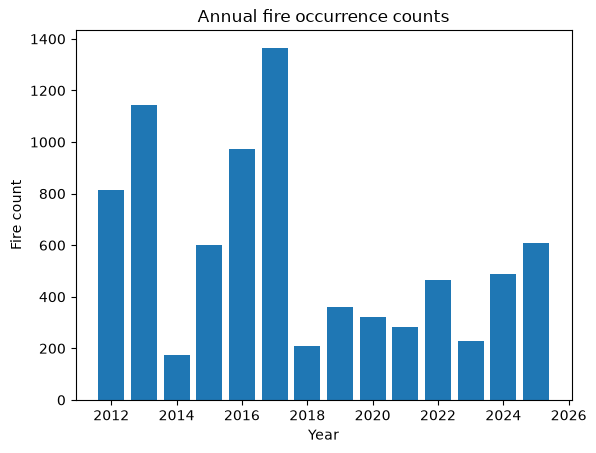

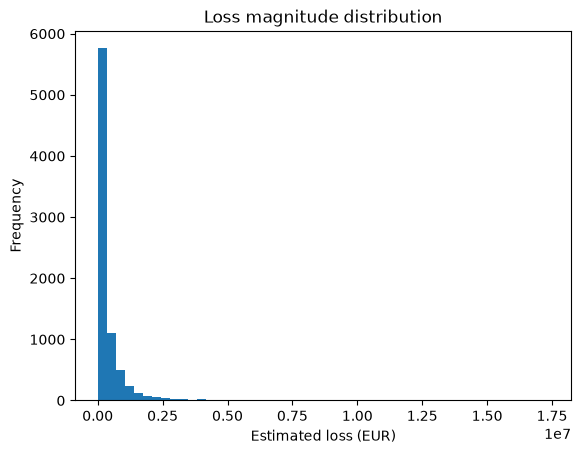

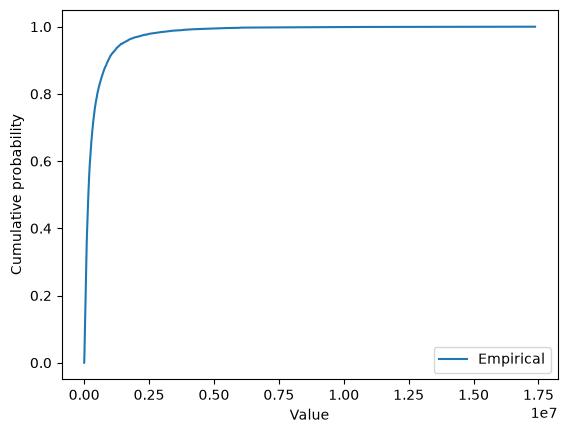

In [11]:
plot_annual_fire_counts(processed_df)
plt.show()

plot_loss_histogram(processed_df)
plt.show()

plot_empirical_cdf(processed_df["Estimated_Loss_EUR"].values)
plt.show()

## Domain validation: order-of-magnitude sanity check

Per the PRD's Domain Validation criterion, checked here early rather than
waiting for Phase 4: does the modeled annual loss land in the right ballpark
for well-documented years?

In [12]:
annual_modeled_loss = processed_df.groupby(processed_df["Date"].dt.year)["Estimated_Loss_EUR"].sum()
print(annual_modeled_loss.map(lambda x: f"EUR {x:,.0f}"))

print("\nReference points from published reporting:")
print("2017 total losses (June + October fires): ~EUR 1.5bn (October 2017 Iberian wildfires)")
print("Typical non-catastrophic year: ~EUR 60-140m/year (OECD/press reporting)")
print("2022 Serra da Estrela fire alone (EMSR618): ~25,000 ha, largest fire in 50 years")
print("2024 Central Madeira fire (EMSR748): >5,000 ha burnt vegetation")

Date
2012      EUR 170,612,394
2013      EUR 342,669,558
2014       EUR 21,053,073
2015       EUR 81,859,269
2016      EUR 309,810,269
2017    EUR 1,006,831,731
2018       EUR 69,516,398
2019       EUR 55,274,613
2020      EUR 103,366,423
2021       EUR 30,753,988
2022      EUR 183,533,192
2023       EUR 53,788,521
2024      EUR 269,396,635
2025      EUR 513,281,923
Name: Estimated_Loss_EUR, dtype: str

Reference points from published reporting:
2017 total losses (June + October fires): ~EUR 1.5bn (October 2017 Iberian wildfires)
Typical non-catastrophic year: ~EUR 60-140m/year (OECD/press reporting)
2022 Serra da Estrela fire alone (EMSR618): ~25,000 ha, largest fire in 50 years
2024 Central Madeira fire (EMSR748): >5,000 ha burnt vegetation


## Data gaps and assumptions

**Frequency and burnt-area data (real, live-fetched):**
- Source: Our World in Data's mirror of GWIS (Global Wildfire Information
  System, JRC/Copernicus - the same body behind EFFIS). EFFIS's own
  Statistics Portal (forest-fire.emergency.copernicus.eu) is a JS
  single-page app with no public JSON endpoint we could find; this live
  CSV mirror was used instead.
- **Gap**: fire-count coverage starts in 2012 (VIIRS), not the full
  2010-2024 window in the original PRD. Burnt-area coverage runs 2002-2025.
  The Poisson frequency fit in Phase 2 will use the 2012+ window.

**Per-fire individual records (synthesized, not real):**
- No free source publishes individual-fire micro-data (date, location,
  size) for Portugal at this granularity. The official channel is EFFIS's
  manual Data Request Form submitted to the JRC; this has been queued as a
  parallel action item (owner: Dan/Kit) but had not arrived as of this
  notebook run, given unknown turnaround time relative to the 6-week
  schedule.
- In its place, `synthesize_fire_events` builds one record per real annual
  fire count, with sizes drawn from a Lognormal shape and rescaled so each
  year's total exactly matches the real GWIS burnt-area figure. **Real
  frequency and real total severity per year are preserved; individual
  records (exact date, region, single-fire size) are illustrative, not
  ground truth for any specific real fire.** If the EFFIS extract arrives,
  this synthesis step should be replaced with the real per-fire table.
- `Location` is sampled uniformly across Portugal's five NUTS2 regions as a
  placeholder; real per-fire locations are unknown without the EFFIS
  extract. Spatial analysis is explicitly out of scope per the PRD, so this
  is not expected to affect the frequency/severity/Monte Carlo modeling.

**Loss calibration (EUR/ha):**
- No source publishes verified EUR loss per individual fire. A single
  documented calibration constant (long-run 1975-2021 ICNF-derived average,
  ~EUR 1,923/ha) is applied uniformly to every synthesized fire's burnt
  area.
- **Known limitation**: real losses are not strictly linear in burnt area -
  a catastrophic wildland-urban-interface fire (e.g. 2017, at an implied
  ~EUR 2,865/ha) carries far higher losses per hectare than a remote
  forest fire, because fatalities and structure loss dominate, not
  hectares burned. This is flagged as a named limitation for the Phase 4/5
  write-up, not hidden in the numbers.
- 2023 was an unusually quiet year for Portugal specifically (27,970 ha
  burnt, the lowest in the recent series) while 2024 was comparatively
  severe (140,086 ha, consistent with real 2024 reporting of Madeira and
  mainland fires). This is a genuine finding worth noting in the write-up:
  the PRD's "2023-2024" window spans one quiet year and one bad year for
  Portugal, even though 2023 was a severe year for the EU as a whole.